# 🃏 BlackjackVAI — Detección y Segmentación de Cartas con YOLO

**Dataset:** BlackjackVAI · ~3000 imágenes · 52 clases (cartas por palo, Joker, reverso)

**Modelo:** YOLOv26m-seg (segmentación de instancias)

**Pipeline:**
1. Descarga del dataset (Roboflow API **o** ZIP desde Drive)
2. Split estratificado 80 / 10 / 10
3. Entrenamiento
4. Visualización de ejemplos post-entrenamiento
5. Evaluación val / test
6. Exportación a Drive
7. Demo en tiempo real con webcam

> **Formato del dataset:** `yolo26` de Roboflow = YOLO Ultralytics segmentation.  
> Las etiquetas son ficheros `.txt` con líneas `class_id x1 y1 x2 y2 … xn yn` (coordenadas normalizadas 0-1).

In [1]:
# ── 0. Montar Google Drive ────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# ── 1. Dependencias ───────────────────────────────────────────────────────────
!pip -q install -U ultralytics pyyaml scikit-learn roboflow

In [12]:
import requests

API_KEY = "sfoh8lecp4kiqvEU7De6"

resp = requests.get(f"https://api.roboflow.com/javiers-workspace-q8mnr?api_key={API_KEY}")
print("Status:", resp.status_code)
data = resp.json()

projects = data.get("workspace", {}).get("projects", [])
print(f"\nProyectos ({len(projects)}):")
for p in projects:
    print(f"  · id={p.get('id')}  name={p.get('name')}  versions={p.get('versions')}")

Status: 200

Proyectos (3):
  · id=javiers-workspace-q8mnr/blackjackvai  name=BlackjackVAI  versions=2
  · id=javiers-workspace-q8mnr/coco_proyecto_1  name=Coco_proyecto_1  versions=0
  · id=javiers-workspace-q8mnr/proyecto_coco_david  name=Proyecto_Coco_David  versions=0


In [16]:
# ── 2. Descarga del dataset desde Roboflow ────────────────────────────────────
#
# Formato descargado: "yolo26" = YOLO Ultralytics segmentation
#   · Imágenes en .jpg / .png
#   · Etiquetas en .txt  →  class_id x1 y1 x2 y2 … xn yn  (0-1 normalizadas)
#   · data.yaml con nombres de clases
#
# NOTA: revisa el número de versión si has publicado una versión más nueva.

from roboflow import Roboflow

rf = Roboflow(api_key="sfoh8lecp4kiqvEU7De6")
project = rf.workspace("javiers-workspace-q8mnr").project("blackjackvai")  # ← minúsculas

# Versión 2 = dataset nuevo con ~3000 imágenes
dataset = project.version(2).download("yolov8")  # ← yolov8 es el formato estándar

print("Dataset descargado en:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BlackjackVAI-2 in yolov8:: 100%|██████████| 6286/6286 [00:00<00:00, 18887.44it/s]

Dataset descargado en: /content/BlackjackVAI-2


In [20]:
# ── 2. Configuración de rutas ─────────────────────────────────────────────────
from pathlib import Path

DATASET_DIR = Path("/content/BlackjackVAI-1")         # /content/BlackjackVAI-2
DATA_YAML     = DATASET_DIR / "data.yaml"
WORKDIR       = Path("/content/blackjack_work")
EXPORT_DIR    = Path("/content/drive/MyDrive/blackjack_exports")
RUN_NAME      = "yolo8m_seg_blackjack"
SEED          = 42
IMGSZ         = 960

WORKDIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Roboflow usa 'valid' — YOLO necesita 'val'; parchear data.yaml si hace falta
import yaml, re

with open(DATA_YAML, "r") as f:
    raw = f.read()

# Fijar rutas absolutas y normalizar 'valid' → 'val'
data = yaml.safe_load(raw)
data["path"] = str(DATASET_DIR)
for key in ["train", "val", "valid", "test"]:
    if key in data:
        val = data.pop(key)
        # normalizar carpeta valid → val
        norm_key = "val" if key == "valid" else key
        norm_val = str(val).replace("/valid/", "/val/").replace("valid/", "val/")
        data[norm_key] = norm_val

# Si la carpeta se llama 'valid' en disco, renombrarla a 'val'
import shutil
valid_dir = DATASET_DIR / "valid"
val_dir   = DATASET_DIR / "val"
if valid_dir.exists() and not val_dir.exists():
    shutil.copytree(valid_dir, val_dir)
    print("Carpeta 'valid' copiada a 'val'")

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

names = data["names"] if isinstance(data["names"], list) else list(data["names"].values())

print(f"Clases ({data['nc']}): {names[:10]} …")
print("data.yaml:", DATA_YAML)
print("\nContenido:")
for p in sorted(DATASET_DIR.iterdir()):
    if p.is_dir():
        imgs = list((p / "images").glob("*")) if (p / "images").exists() else list(p.glob("*"))
        print(f"  {p.name}/  → {len(imgs)} ficheros")
    else:
        print(f"  {p.name}")

Clases (54): ['10 Clubs', '10 Diamonds', '10 Hearts', '10 Spades', '2 Clubs', '2 Diamonds', '2 Hearts', '2 Spades', '3 Clubs', '3 Diamonds'] …
data.yaml: /content/BlackjackVAI-1/data.yaml

Contenido:
  README.roboflow.txt
  data.yaml
  test/  → 1021 ficheros
  train/  → 8526 ficheros
  val/  → 1019 ficheros
  valid/  → 1019 ficheros


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


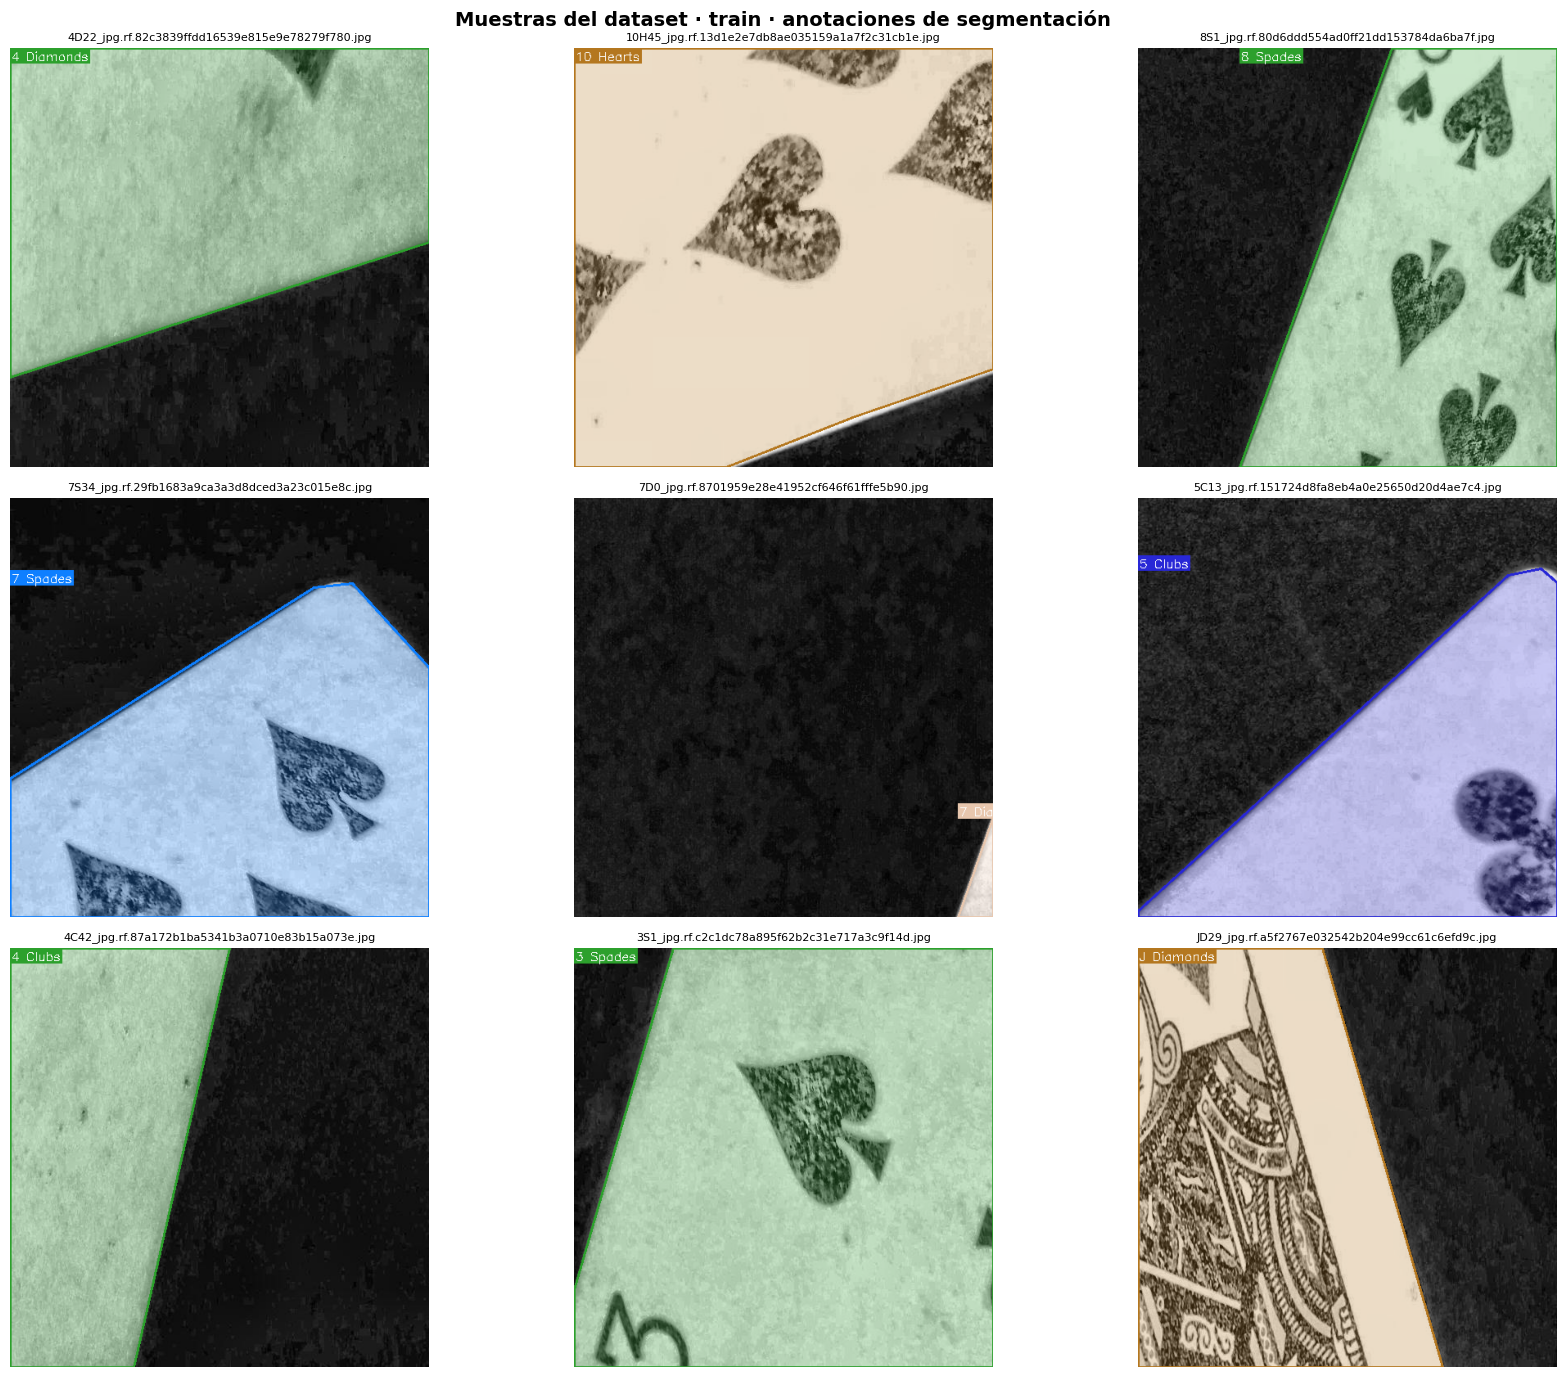

In [21]:
# ── 3. Visualización del dataset (9 muestras de train) ───────────────────────
import cv2, random, yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

random.seed(SEED)

CMAP = plt.cm.get_cmap("tab20", len(names))

def bgr_color(cls_id):
    r, g, b, _ = CMAP(cls_id % 20)
    return (int(b*255), int(g*255), int(r*255))

def draw_sample(img_path: Path, lbl_path: Path):
    img = cv2.imread(str(img_path))
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if not lbl_path.exists(): return img
    for ln in lbl_path.read_text(encoding="utf-8").splitlines():
        toks = ln.strip().split()
        if not toks: continue
        cls_id = int(float(toks[0]))
        coords = np.array(list(map(float, toks[1:])), dtype=np.float32).reshape(-1, 2)
        coords[:, 0] *= w; coords[:, 1] *= h
        pts = coords.astype(np.int32)
        color = bgr_color(cls_id)
        if len(pts) >= 3:
            ov = img.copy()
            cv2.fillPoly(ov, [pts], color)
            img = cv2.addWeighted(ov, 0.25, img, 0.75, 0)
            cv2.polylines(img, [pts], True, color, 2)
        x0, y0 = pts.min(axis=0)
        label = names[cls_id] if cls_id < len(names) else f"cls_{cls_id}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        y0c = max(y0, th + 4)
        cv2.rectangle(img, (x0, y0c-th-4), (x0+tw+2, y0c+2), color, -1)
        cv2.putText(img, label, (x0+1, y0c-1), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    return img

# Buscar carpeta train (puede ser train/images/ o train/ directamente)
train_img_dir = DATASET_DIR / "train" / "images"
if not train_img_dir.exists():
    train_img_dir = DATASET_DIR / "train"

train_imgs = sorted(train_img_dir.glob("*.*"))
samples    = random.sample(train_imgs, min(9, len(train_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, img_path in zip(axes.flatten(), samples):
    lbl_dir  = img_path.parent.parent / "labels" if "images" in img_path.parent.name else img_path.parent.parent / "labels"
    lbl_path = lbl_dir / f"{img_path.stem}.txt"
    if not lbl_path.exists():
        lbl_path = img_path.with_suffix(".txt")
    ann = draw_sample(img_path, lbl_path)
    if ann is not None:
        ax.imshow(ann)
        ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.suptitle("Muestras del dataset · train · anotaciones de segmentación",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
# ── FIX: limpiar etiquetas mixtas detect/segment ──────────────────────────────
from pathlib import Path

def fix_labels(label_dir: Path):
    n_fixed = 0
    for lbl in label_dir.glob("*.txt"):
        lines = lbl.read_text(encoding="utf-8").splitlines()
        seg_lines = [
            ln for ln in lines
            if ln.strip() and
                len(ln.strip().split()) > 5 and
                (len(ln.strip().split()) - 1) % 2 == 0
        ]
        if len(seg_lines) != len([l for l in lines if l.strip()]):
            lbl.write_text("\n".join(seg_lines), encoding="utf-8")
            n_fixed += 1
    return n_fixed

for split in ["train", "val", "test"]:
    lbl_dir = DATASET_DIR / split / "labels"
    if lbl_dir.exists():
        n = fix_labels(lbl_dir)
        print(f"{split}: {n} ficheros corregidos")

# Borrar caches para que YOLO reescanee
for cache in DATASET_DIR.rglob("*.cache"):
    cache.unlink()
    print("Eliminado:", cache)

print("Listo — ahora ejecuta la celda de entrenamiento.")

train: 4 ficheros corregidos
val: 0 ficheros corregidos
test: 0 ficheros corregidos
Eliminado: /content/BlackjackVAI-1/val/labels.cache
Eliminado: /content/BlackjackVAI-1/train/labels.cache
Listo — ahora ejecuta la celda de entrenamiento.


In [24]:
# ── 4. Entrenamiento ──────────────────────────────────────────────────────────
from ultralytics import YOLO
from pathlib import Path

EPOCHS   = 100
BATCH    = 8
PATIENCE = 30

model = YOLO("yolov8m-seg.pt")

model.train(
    data         = str(DATA_YAML),
    task         = "segment",
    epochs       = EPOCHS,
    imgsz        = IMGSZ,
    batch        = BATCH,
    device       = 0,
    workers      = 2,
    seed         = SEED,
    pretrained   = True,
    amp          = True,
    cache        = False,
    cos_lr       = True,
    patience     = PATIENCE,
    plots        = True,
    save         = True,
    project      = str(WORKDIR / "runs"),
    name         = RUN_NAME,
    exist_ok     = True,
    # ── Augmentations ────────────────────────────────────────────
    hsv_h        = 0.02,
    hsv_s        = 0.75,
    hsv_v        = 0.45,
    degrees      = 12.0,
    translate    = 0.12,
    scale        = 0.35,
    shear        = 3.0,
    flipud       = 0.20,
    fliplr       = 0.50,
    mosaic       = 1.0,
    mixup        = 0.15,
    copy_paste   = 0.30,
    close_mosaic = 10,
    overlap_mask = True,
    mask_ratio   = 4
)

RUN_DIR = str(model.trainer.save_dir)
BEST_PT = str(Path(RUN_DIR) / "weights" / "best.pt")
LAST_PT = str(Path(RUN_DIR) / "weights" / "last.pt")

print("\nEntrenamiento completado.")
print("best.pt →", BEST_PT)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/BlackjackVAI-1/data.yaml, degrees=12.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.75, hsv_v=0.45, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo8m_seg_blackjack, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

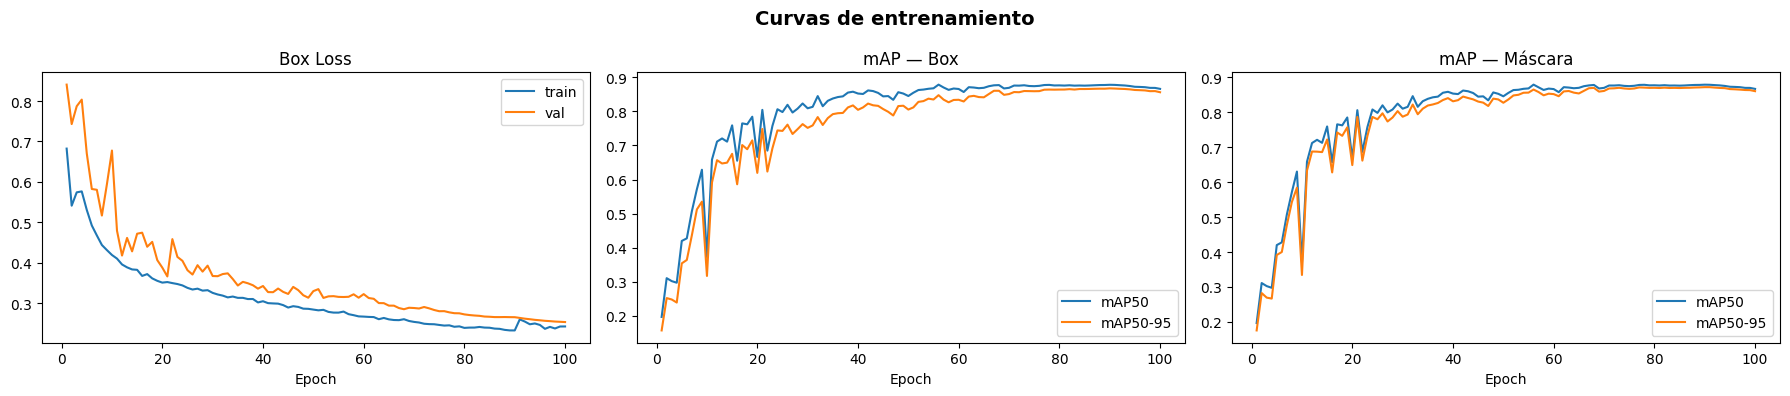

Predicciones en validación…


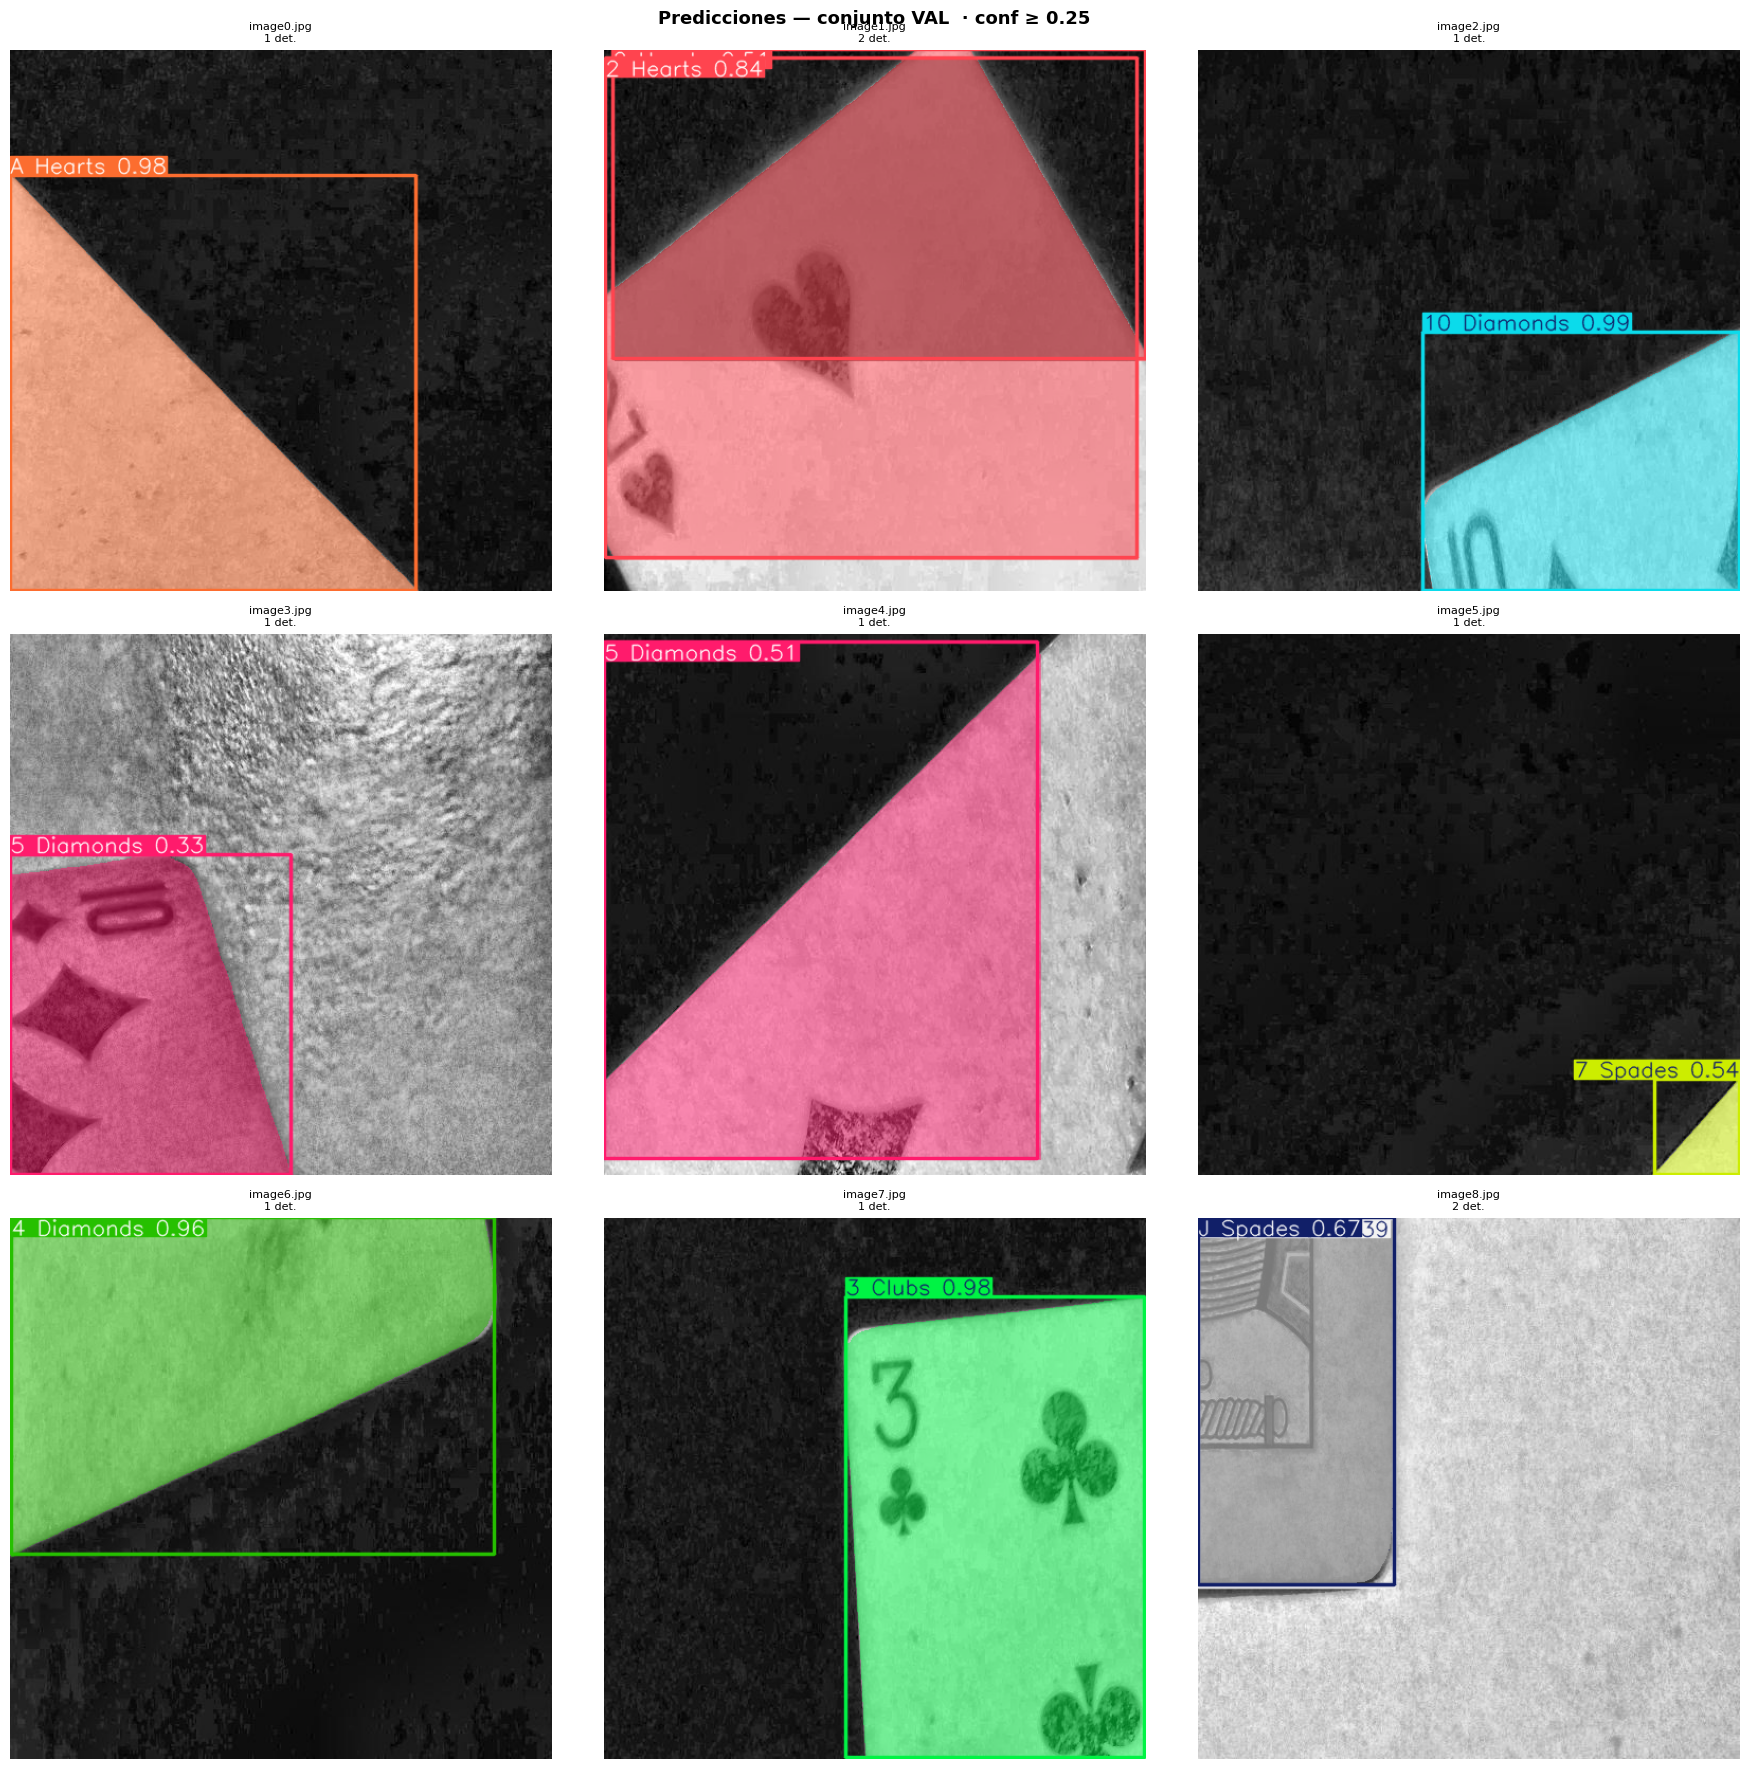

Predicciones en test…


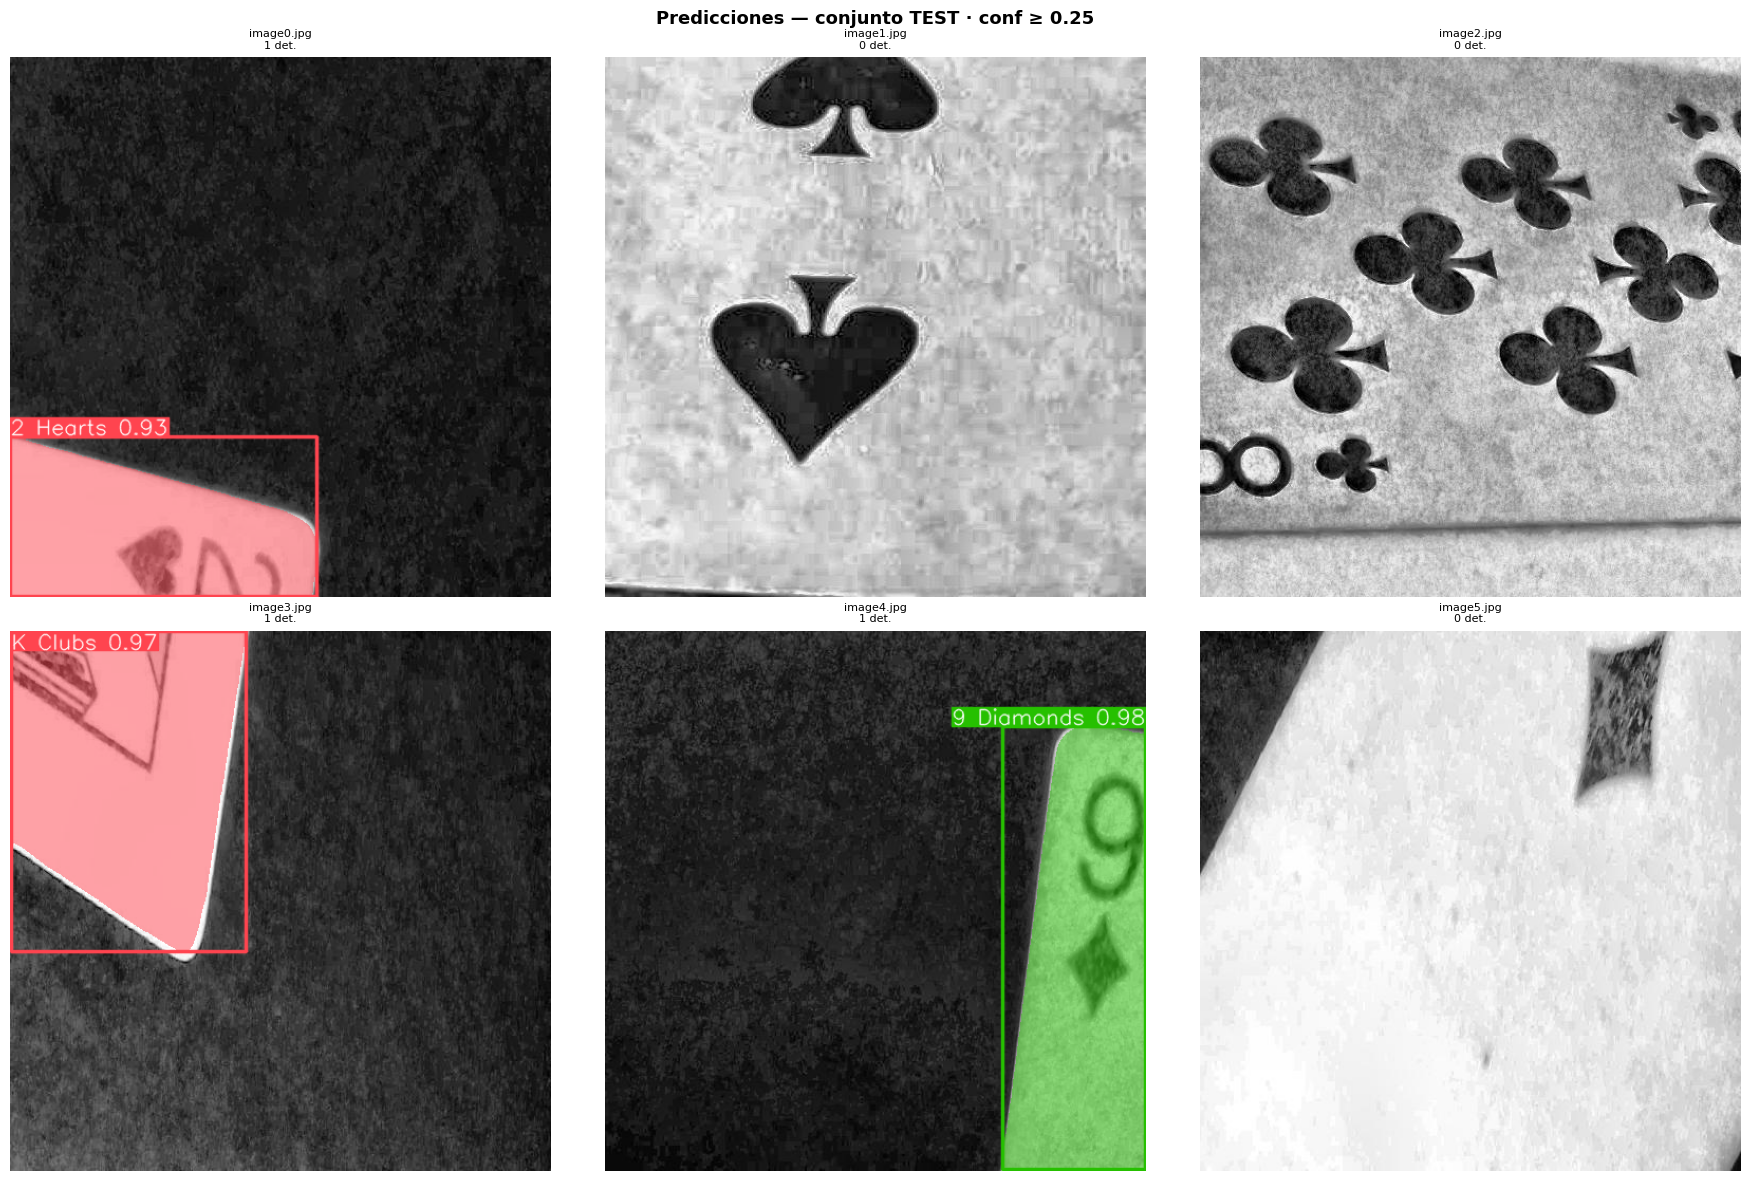

In [25]:
# ── 5. Visualización post-entrenamiento ───────────────────────────────────────
import cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

random.seed(SEED)

# ── 5a. Curvas de entrenamiento ───────────────────────────────────
results_csv = Path(RUN_DIR) / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for col, lbl in [("train/box_loss", "train"), ("val/box_loss", "val")]:
        if col in df.columns: axes[0].plot(df["epoch"], df[col], label=lbl)
    axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    for col, lbl in [("metrics/mAP50(B)", "mAP50"), ("metrics/mAP50-95(B)", "mAP50-95")]:
        if col in df.columns: axes[1].plot(df["epoch"], df[col], label=lbl)
    axes[1].set_title("mAP — Box"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    for col, lbl in [("metrics/mAP50(M)", "mAP50"), ("metrics/mAP50-95(M)", "mAP50-95")]:
        if col in df.columns: axes[2].plot(df["epoch"], df[col], label=lbl)
    axes[2].set_title("mAP — Máscara"); axes[2].set_xlabel("Epoch"); axes[2].legend()

    plt.suptitle("Curvas de entrenamiento", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

# ── 5b. Grid de predicciones (val) ───────────────────────────────
def pred_grid(model_path, img_dir: Path, title: str, n=9, conf=0.25):
    m    = YOLO(model_path)
    imgs = sorted(img_dir.rglob("*.*"))
    imgs = [p for p in imgs if p.suffix.lower() in {".jpg",".jpeg",".png"}]
    samp = random.sample(imgs, min(n, len(imgs)))
    preds = m.predict(source=[str(p) for p in samp], imgsz=IMGSZ, conf=conf, verbose=False)

    cols = 3; rows = (len(preds) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
    axes = np.array(axes).flatten()
    for i, res in enumerate(preds):
        ann  = cv2.cvtColor(res.plot(line_width=2), cv2.COLOR_BGR2RGB)
        dets = len(res.boxes) if res.boxes is not None else 0
        axes[i].imshow(ann)
        axes[i].set_title(f"{Path(res.path).name}\n{dets} det.", fontsize=8)
        axes[i].axis("off")
    for j in range(len(preds), len(axes)): axes[j].axis("off")
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

val_img_dir  = DATASET_DIR / "val"  / "images"
test_img_dir = DATASET_DIR / "test" / "images"
if not val_img_dir.exists():  val_img_dir  = DATASET_DIR / "valid" / "images"

print("Predicciones en validación…")
pred_grid(BEST_PT, val_img_dir,  "Predicciones — conjunto VAL  · conf ≥ 0.25", n=9)

if test_img_dir.exists():
    print("Predicciones en test…")
    pred_grid(BEST_PT, test_img_dir, "Predicciones — conjunto TEST · conf ≥ 0.25", n=6)

In [26]:
# ── 6. Evaluación cuantitativa (val + test) ───────────────────────────────────
from ultralytics import YOLO

best_model = YOLO(BEST_PT)

val_metrics  = best_model.val(data=str(DATA_YAML), split="val",  imgsz=IMGSZ, device=0, plots=True)
test_metrics = best_model.val(data=str(DATA_YAML), split="test", imgsz=IMGSZ, device=0, plots=True)

def print_metrics(label, m):
    d = m.results_dict
    print(f"\n{'═'*50}")
    print(f"  {label}")
    print(f"{'═'*50}")
    print(f"  Box   P={d.get('metrics/precision(B)',0):.3f}  R={d.get('metrics/recall(B)',0):.3f}  "
          f"mAP50={d.get('metrics/mAP50(B)',0):.3f}  mAP50-95={d.get('metrics/mAP50-95(B)',0):.3f}")
    print(f"  Mask  P={d.get('metrics/precision(M)',0):.3f}  R={d.get('metrics/recall(M)',0):.3f}  "
          f"mAP50={d.get('metrics/mAP50(M)',0):.3f}  mAP50-95={d.get('metrics/mAP50-95(M)',0):.3f}")

print_metrics("VALIDACIÓN", val_metrics)
print_metrics("TEST",       test_metrics)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,253,650 parameters, 0 gradients, 104.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1049.7±543.8 MB/s, size: 27.8 KB)
val: Scanning /content/BlackjackVAI-1/val/labels.cache... 1019 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1019/1019 388.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 8.2it/s 7.8s
                   all       1019       1049      0.901      0.786      0.878      0.867      0.901      0.786      0.878      0.871
              10 Clubs         29         29      0.946      0.609      0.863      0.846      0.946      0.609      0.863      0.838
           10 Diamonds         39         39       0.92      0.923      0.969      0.966       0.92      0.923      0.969      0.969
             10 Hea

In [27]:
# ── 7. Exportar pesos a Google Drive ─────────────────────────────────────────
import shutil
from datetime import datetime
from pathlib import Path

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_DIR  = EXPORT_DIR / f"{RUN_NAME}_{timestamp}"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

BEST_PT_DRIVE = str(SAVE_DIR / "best.pt")

shutil.copy2(BEST_PT, BEST_PT_DRIVE)
shutil.copy2(LAST_PT, SAVE_DIR / "last.pt")
shutil.copy2(DATA_YAML, SAVE_DIR / "data.yaml")
for plot in Path(RUN_DIR).glob("*.png"):
    shutil.copy2(plot, SAVE_DIR / plot.name)

print("Guardado en Drive:")
for f in sorted(SAVE_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")

Guardado en Drive:
  BoxF1_curve.png  (0.6 MB)
  BoxPR_curve.png  (0.2 MB)
  BoxP_curve.png  (0.5 MB)
  BoxR_curve.png  (0.4 MB)
  MaskF1_curve.png  (0.6 MB)
  MaskPR_curve.png  (0.2 MB)
  MaskP_curve.png  (0.5 MB)
  MaskR_curve.png  (0.4 MB)
  best.pt  (55.0 MB)
  confusion_matrix.png  (0.4 MB)
  confusion_matrix_normalized.png  (0.4 MB)
  data.yaml  (0.0 MB)
  last.pt  (55.0 MB)
  results.png  (0.4 MB)


Modelo: /content/drive/MyDrive/blackjack_exports/yolo8m_seg_blackjack_20260426_225920/best.pt


<IPython.core.display.Javascript object>

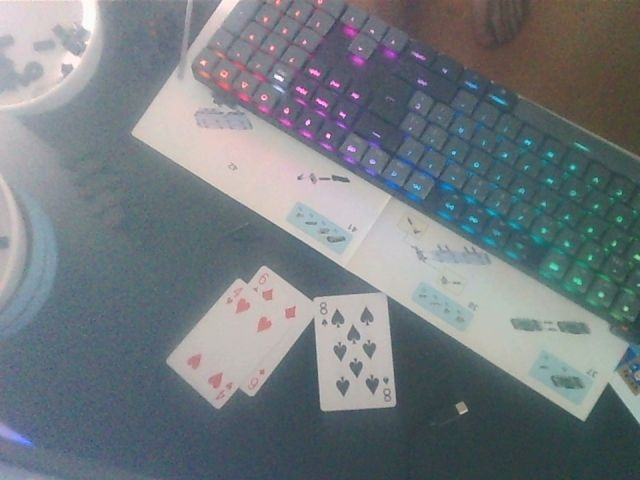

Webcam iniciada. Para detener: botón ■ de Colab.
Detenido.
Webcam cerrada.


In [29]:
# ── 8. Demo webcam en tiempo real ────────────────────────────────────────────
#
# Chrome / Edge recomendados. Para detener: botón ■ de Colab.

import cv2, numpy as np
from base64 import b64decode
from IPython.display import Javascript, display, Image as IPImage
from google.colab.output import eval_js
from ultralytics import YOLO

webcam_model = YOLO(BEST_PT_DRIVE)
print(f"Modelo: {BEST_PT_DRIVE}")

display(Javascript('''
async function initWebcam() {
  if (window._bjStream) window._bjStream.getTracks().forEach(t => t.stop());
  const video = document.createElement("video");
  video.style.cssText = "border:2px solid #444;border-radius:8px;display:block;margin:8px auto;";
  video.width = 640; video.height = 480; video.autoplay = true; video.playsInline = true;
  document.body.appendChild(video);
  const stream = await navigator.mediaDevices.getUserMedia({video:{width:640,height:480}});
  window._bjStream = stream; window._bjVideo = video;
  window._bjCanvas = document.createElement("canvas");
  video.srcObject = stream;
  const lbl = document.createElement("p");
  lbl.textContent = "Webcam activa — BlackjackVAI";
  lbl.style.cssText = "text-align:center;font-family:monospace;font-size:13px;";
  document.body.appendChild(lbl);
  return "ok";
}
async function captureFrame() {
  const v = window._bjVideo, c = window._bjCanvas;
  if (!v) return null;
  c.width = v.videoWidth || 640; c.height = v.videoHeight || 480;
  c.getContext("2d").drawImage(v, 0, 0, c.width, c.height);
  return c.toDataURL("image/jpeg", 0.8);
}
function stopWebcam() {
  if (window._bjStream) window._bjStream.getTracks().forEach(t => t.stop());
  return "stopped";
}
'''))

eval_js("initWebcam()")

blank = np.zeros((480, 640, 3), dtype=np.uint8)
_, blank_jpg = cv2.imencode(".jpg", blank)
dh = display(IPImage(data=blank_jpg.tobytes()), display_id=True)

print("Webcam iniciada. Para detener: botón ■ de Colab.")
try:
    while True:
        data = eval_js("captureFrame()")
        if not data: continue
        frame = cv2.imdecode(
            np.frombuffer(b64decode(data.split(",", 1)[1]), np.uint8),
            cv2.IMREAD_COLOR
        )
        res = webcam_model.predict(source=frame, imgsz=640, conf=0.35, verbose=False)
        _, jpg = cv2.imencode(".jpg", res[0].plot(line_width=2))
        dh.update(IPImage(data=jpg.tobytes()))
except KeyboardInterrupt:
    print("Detenido.")
finally:
    eval_js("stopWebcam()")
    print("Webcam cerrada.")